In [1]:
# Imports
import numpy as np
from numpy.linalg import norm, svd
import matplotlib.pyplot as plt

In [8]:
# Functions
def normalize_columns(D):
    return D / np.maximum(norm(D, axis=0, keepdims=True), 1e-12)

# m: number of rows in X
# K: number of atoms in dictionary
# N: number of columns in X, dimension of signal
# T0: sparsity level
def generate_synthetic(m=20, K=40, N=200, T0=3, seed=0):
    np.random.seed(seed)

    D_true = np.random.randn(m, K)
    D_true = normalize_columns(D_true)

    C_true = np.zeros((K, N))
    for i in range(N):
        support = np.random.choice(K, T0, replace=False)
        C_true[support, i] = np.random.randn(T0)

    X = D_true @ C_true
    return D_true, C_true, X

def omp(D, x, T0):
    m, K = D.shape
    residual = x.copy()
    support = []

    for _ in range(T0):
        correlations = D.T @ residual
        idx = np.argmax(np.abs(correlations))
        if idx in support:
            break
        support.append(idx)

        Ds = D[:, support]
        c_s, *_ = np.linalg.lstsq(Ds, x, rcond=None)
        residual = x - Ds @ c_s

        if norm(residual) < 1e-6:
            break

    c = np.zeros(K)
    c[support] = c_s
    return c

errors = []
def ksvd(X, K, T0, n_iter=10):
    m, N = X.shape

    # Initialize dictionary randomly from data
    D = X[:, np.random.choice(N, K, replace=False)]
    D = normalize_columns(D)

    C = np.zeros((K, N))

    for it in range(n_iter):
        print(f"Iteration {it+1}")

        # ---- Sparse Coding ----
        for i in range(N):
            C[:, i] = omp(D, X[:, i], T0)

        # ---- Dictionary Update ----
        for k in range(K):
            idx = np.nonzero(C[k, :])[0]
            if len(idx) == 0:
                continue

            # Compute residual excluding atom k
            E = X[:, idx] - D @ C[:, idx] + np.outer(D[:, k], C[k, idx])

            # Rank-1 SVD
            U, S, Vt = svd(E, full_matrices=False)

            D[:, k] = U[:, 0]
            C[k, idx] = S[0] * Vt[0, :]

        D = normalize_columns(D)

        # Track reconstruction error
        error = norm(X - D @ C) / norm(X)
        print("Reconstruction error:", error)
        errors.append(error)

    return D, C

In [9]:
# Validation
def reconstruction_error(X, D, C):
    return norm(X - D @ C) / norm(X)
def dictionary_recovery_score(D_true, D_learned):
    sims = np.abs(D_true.T @ D_learned)
    return np.mean(np.max(sims, axis=1))

In [10]:
# Test
m, K, N, T0 = 20, 40, 200, 3

D_true, C_true, X = generate_synthetic(m, K, N, T0)

D_learned, C_learned = ksvd(X, K, T0, n_iter=10)

print("\nFinal Reconstruction Error:", reconstruction_error(X, D_learned, C_learned))
print("Dictionary Recovery Score:", dictionary_recovery_score(D_true, D_learned))

Iteration 1
Reconstruction error: 0.35340614211636345
Iteration 2
Reconstruction error: 0.2954929188892667
Iteration 3
Reconstruction error: 0.28064528422290974
Iteration 4
Reconstruction error: 0.27916213085730657
Iteration 5
Reconstruction error: 0.2666654077719496
Iteration 6
Reconstruction error: 0.26238070996142104
Iteration 7
Reconstruction error: 0.25865286563768247
Iteration 8
Reconstruction error: 0.2567715907193973
Iteration 9
Reconstruction error: 0.25459826655599666
Iteration 10
Reconstruction error: 0.24867377060220558

Final Reconstruction Error: 0.24867377060220558
Dictionary Recovery Score: 0.8118019625951771


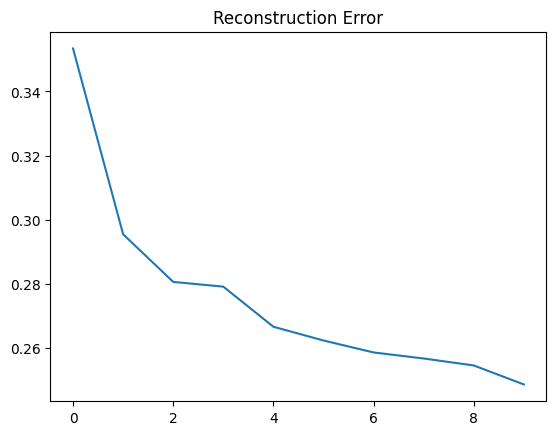

In [11]:
plt.plot(errors)
plt.title("Reconstruction Error")
plt.show()